# Week 1 — Introduction to Machine Learning

One small, real dataset is used for the whole course: **daily weather in Seattle, 2012–2015**
(1,461 days: rain, temperatures, wind). Everything is short Python that you can read top to bottom.

**Practice tasks covered**
1. Import, load and view the dataset
2. Summary and statistics (missing values, skew, seasonality, correlation)

Plus two small ideas that every later week uses: **Bayes' rule** and **over-fitting**.

## Practice 1 — Load and view the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from weather import load

d = load()
d.head()

,date,precipitation,temp_max,temp_min,wind,weather,rain,month_sin,month_cos,rain_tomorrow,temp_tomorrow
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle,0,0.5,0.866025,1.0,10.6
1,2012-01-02,10.9,10.6,2.8,4.5,rain,1,0.5,0.866025,1.0,11.7
2,2012-01-03,0.8,11.7,7.2,2.3,rain,1,0.5,0.866025,1.0,12.2
3,2012-01-04,20.3,12.2,5.6,4.7,rain,1,0.5,0.866025,1.0,8.9
4,2012-01-05,1.3,8.9,2.8,6.1,rain,1,0.5,0.866025,1.0,4.4


In [2]:
print("rows and columns:", d.shape)
print("first day:", d.date.min().date(), "| last day:", d.date.max().date())
d.dtypes

rows and columns: (1461, 11)
first day: 2012-01-01 | last day: 2015-12-31


date             datetime64[us]
precipitation           float64
temp_max                float64
temp_min                float64
wind                    float64
weather                     str
rain                      int64
month_sin               float64
month_cos               float64
rain_tomorrow           float64
temp_tomorrow           float64
dtype: object

Each row is one day. `weather` is a label (sun, rain, drizzle, fog, snow) that the dataset's authors
built from the other columns, so the course never uses it as an input: it would be cheating.
The helper `weather.py` adds a few columns: `rain` (1 if precipitation > 0), `rain_tomorrow`
and `temp_tomorrow` (the things we will predict), and the month as a circle (`month_sin`, `month_cos`).

In [3]:
d.weather.value_counts()

weather
rain       641
sun        640
fog        101
drizzle     53
snow        26
Name: count, dtype: int64

## Practice 2 — Summary and statistics

In [4]:
cols = ["precipitation", "temp_max", "temp_min", "wind"]
print("missing values per column:")
print(d[cols + ["weather"]].isna().sum())
d[cols].describe().round(1)

missing values per column:
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64


,precipitation,temp_max,temp_min,wind
count,1461.0,1461.0,1461.0,1461.0
mean,3.0,16.4,8.2,3.2
std,6.7,7.3,5.0,1.4
min,0.0,-1.6,-7.1,0.4
25%,0.0,10.6,4.4,2.2
50%,0.0,15.6,8.3,3.0
75%,2.8,22.2,12.2,4.0
max,55.9,35.6,18.3,9.5


No values are missing. Notice that precipitation has a median of 0 but a maximum of about 56 mm:
most days are dry and a few are very wet. That is a **skewed** distribution.

skew of precipitation: 3.51
skew of temp_max:      0.28


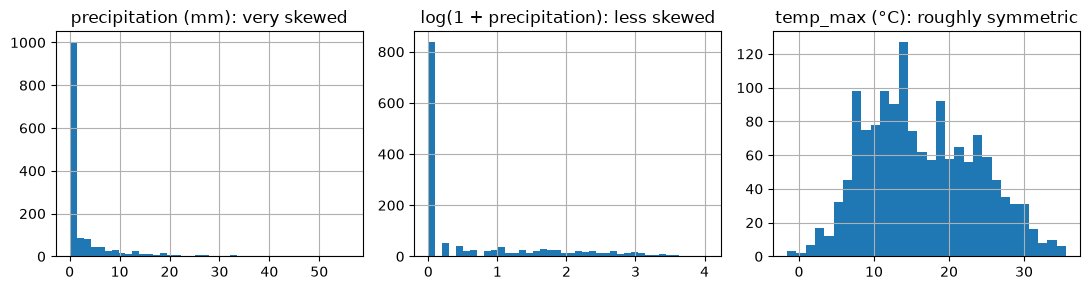

In [5]:
print("skew of precipitation:", round(d.precipitation.skew(), 2))
print("skew of temp_max:     ", round(d.temp_max.skew(), 2))
fig, ax = plt.subplots(1, 3, figsize=(11, 3))
d.precipitation.hist(bins=40, ax=ax[0]);          ax[0].set_title("precipitation (mm): very skewed")
np.log1p(d.precipitation).hist(bins=40, ax=ax[1]); ax[1].set_title("log(1 + precipitation): less skewed")
d.temp_max.hist(bins=30, ax=ax[2]);               ax[2].set_title("temp_max (°C): roughly symmetric")
plt.tight_layout(); plt.show()

### Seasonality: the weather depends strongly on the time of year

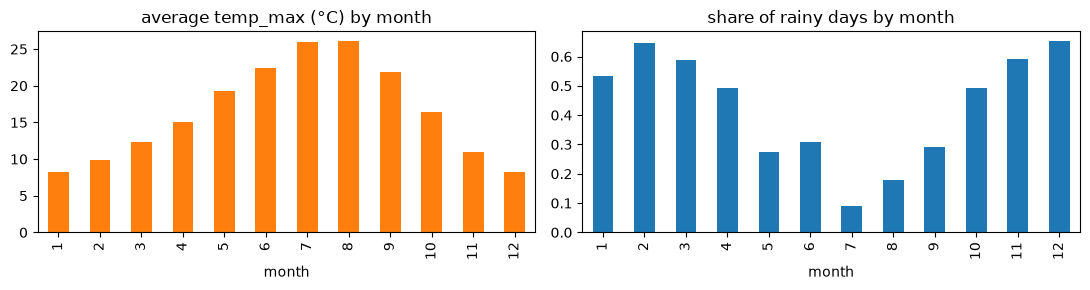

In [6]:
by_month = d.groupby(d.date.dt.month).agg(temp_max=("temp_max", "mean"), rain_share=("rain", "mean"))
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
by_month.temp_max.plot.bar(ax=ax[0], color="tab:orange"); ax[0].set_title("average temp_max (°C) by month")
by_month.rain_share.plot.bar(ax=ax[1], color="tab:blue"); ax[1].set_title("share of rainy days by month")
for a in ax: a.set_xlabel("month")
plt.tight_layout(); plt.show()

### Correlation: which columns move together?

               precipitation  temp_max  temp_min  wind
precipitation           1.00     -0.23     -0.07  0.33
temp_max               -0.23      1.00      0.88 -0.16
temp_min               -0.07      0.88      1.00 -0.07
wind                    0.33     -0.16     -0.07  1.00


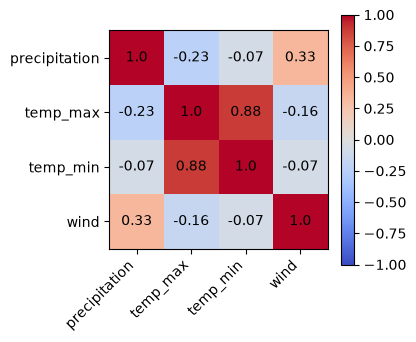

In [7]:
corr = d[cols].corr().round(2)
print(corr)
plt.figure(figsize=(4.2, 3.6)); plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(4), cols, rotation=45, ha="right"); plt.yticks(range(4), cols)
for i in range(4):
    for j in range(4): plt.text(j, i, corr.iloc[i, j], ha="center", va="center")
plt.colorbar(); plt.tight_layout(); plt.show()

`temp_max` and `temp_min` move together (both follow the seasons). Wind and rain are only weakly related to temperature.

## Idea 1 — Bayes' rule with real data

*If it rains today, how likely is rain tomorrow?* Bayes' rule says
$P(A\mid B) = P(B\mid A)\,P(A) / P(B)$. Here we count it directly and also with the rule.

In [8]:
t = d.dropna()
p_rain = t.rain_tomorrow.mean()                                  # P(rain tomorrow)
p_today_given_rain = t[t.rain_tomorrow == 1].rain.mean()         # P(rain today | rain tomorrow)
p_today = t.rain.mean()                                          # P(rain today)
bayes = p_today_given_rain * p_rain / p_today
direct = t[t.rain == 1].rain_tomorrow.mean()
print(f"P(rain tomorrow)                    = {p_rain:.3f}   <- prior")
print(f"P(rain tomorrow | rain today), Bayes = {bayes:.3f}")
print(f"P(rain tomorrow | rain today), count = {direct:.3f}")
print(f"P(rain tomorrow | dry today)         = {t[t.rain == 0].rain_tomorrow.mean():.3f}")

P(rain tomorrow)                    = 0.427   <- prior
P(rain tomorrow | rain today), Bayes = 0.673
P(rain tomorrow | rain today), count = 0.673
P(rain tomorrow | dry today)         = 0.244


Knowing it rained today lifts the chance of rain tomorrow from 43% to 67%. The weather has memory,
which is exactly what weeks 4 and 5 make use of.

## Idea 2 — Over-fitting

A model that is too flexible memorises the training data and does worse on new data.
We fit polynomials of growing degree to the yearly temperature cycle, trained on 2012–2014 and tested on 2015.

In [9]:
day = d.date.dt.dayofyear / 365                      # position in the year, 0 to 1
train, test = d.date < "2015-01-01", d.date >= "2015-01-01"
print("degree  train error  test error   (RMSE in °C)")
for degree in [1, 2, 4, 8, 16, 24]:
    curve = np.polynomial.Polynomial.fit(day[train], d.temp_max[train], degree)
    rmse = lambda m: np.sqrt(((d.temp_max[m] - curve(day[m])) ** 2).mean())
    print(f"{degree:>6}  {rmse(train):>11.2f}  {rmse(test):>10.2f}")

degree  train error  test error   (RMSE in °C)
     1         7.20        7.52
     2         4.31        4.49
     4         3.66        3.89
     8         3.48        3.86
    16         3.45        3.95
    24         3.41        3.98


The training error keeps shrinking, but the test error is lowest around degree 8 and then gets worse.
A simple model that captures the yearly cycle is enough.

## Summary
* 1,461 days, 4 numeric columns, nothing missing; precipitation is very skewed; temperature follows the seasons.
* Rain has memory: a rainy day makes a rainy tomorrow much more likely (Bayes' rule).
* More flexible is not always better: judge a model on data it has not seen (train 2012–2014, test 2015).